## Imports and Configuration ##

In [1]:

import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from pandas.api.types import CategoricalDtype

from category_encoders import MEstimateEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import KFold, cross_val_score
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler

# Reproducibility
import random
np.random.seed(0)
random.seed(0)
os.environ["PYTHONHASHSEED"] = "0"

# Set Matplotlib defaults
plt.style.use("seaborn-v0_8-whitegrid")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)

# Mute warnings
warnings.filterwarnings('ignore')


## Data Preprocessing ##
- **Load** the data from CSV files
- **Clean** the data to fix any errors or inconsistencies
- **Encode** the statistical data type (numeric, categorical)
- **Impute** any missing values

In [2]:
def load_data():
    # Read data
    data_dir = Path("../Datasets/House_Price_Prediction")
    df_train = pd.read_csv(data_dir / "train.csv", index_col="Id")
    df_test = pd.read_csv(data_dir / "test.csv", index_col="Id")
    # Ensure SalePrice exists on test for consistent columns
    df_test = df_test.copy()
    df_test["SalePrice"] = np.nan
    # Merge the splits so we can process them together
    df = pd.concat([df_train, df_test], copy=True)
    # Preprocessing
    df = clean(df)
    df = encode(df)
    df = impute(df)
    # Reform splits
    df_train = df.loc[df_train.index, :].copy()
    df_test = df.loc[df_test.index, :].copy()
    return df_train, df_test


### Clean Data ##

In [3]:
data_dir = Path("../Datasets/House_Price_Prediction")
df = pd.read_csv(data_dir / "train.csv", index_col="Id")

df.Exterior2nd.unique()

<StringArray>
['VinylSd', 'MetalSd', 'Wd Shng', 'HdBoard', 'Plywood', 'Wd Sdng', 'CmentBd',
 'BrkFace',  'Stucco', 'AsbShng', 'Brk Cmn', 'ImStucc', 'AsphShn',   'Stone',
   'Other',  'CBlock']
Length: 16, dtype: str

In [4]:
def clean(df):
    df = df.copy()
    df["Exterior2nd"] = df["Exterior2nd"].replace({"Brk Cmn": "BrkComm"})
    # Some values of GarageYrBlt are corrupt, so we'll replace them
    # with the year the house was built
    df["GarageYrBlt"] = df["GarageYrBlt"].where(df.GarageYrBlt <= 2010, df.YearBuilt)
    # Names beginning with numbers are awkward to work with
    df.rename(columns={
        "1stFlrSF": "FirstFlrSF",
        "2ndFlrSF": "SecondFlrSF",
        "3SsnPorch": "Threeseasonporch",
    }, inplace=True,
    )
    # Normalize string columns: strip whitespace and ensure string type
    str_cols = df.select_dtypes(include=['object']).columns
    for c in str_cols:
        df[c] = df[c].astype(str).str.strip()
    # Ensure MSSubClass is string-coded category
    if "MSSubClass" in df.columns:
        df["MSSubClass"] = df["MSSubClass"].astype(str)
    return df


### Encode the Statistical Data Type ###

In [5]:

# The numeric features are already encoded correctly (`float` for
# continuous, `int` for discrete), but the categoricals we'll need to
# do ourselves. Note in particular, that the `MSSubClass` feature is
# read as an `int` type, but is actually a (nominative) categorical.

# The nominative (unordered) categorical features
features_nom = ["MSSubClass", "MSZoning", "Street", "Alley", "LandContour", "LotConfig", "Neighborhood", "Condition1", "Condition2", "BldgType", "HouseStyle", "RoofStyle", "RoofMatl", "Exterior1st", "Exterior2nd", "MasVnrType", "Foundation", "Heating", "CentralAir", "GarageType", "MiscFeature", "SaleType", "SaleCondition"]


# The ordinal (ordered) categorical features 

# Pandas calls the categories "levels"
five_levels = ["Po", "Fa", "TA", "Gd", "Ex"]
ten_levels = list(range(10))

ordered_levels = {
    "OverallQual": ten_levels,
    "OverallCond": ten_levels,
    "ExterQual": five_levels,
    "ExterCond": five_levels,
    "BsmtQual": five_levels,
    "BsmtCond": five_levels,
    "HeatingQC": five_levels,
    "KitchenQual": five_levels,
    "FireplaceQu": five_levels,
    "GarageQual": five_levels,
    "GarageCond": five_levels,
    "PoolQC": five_levels,
    "LotShape": ["Reg", "IR1", "IR2", "IR3"],
    "LandSlope": ["Sev", "Mod", "Gtl"],
    "BsmtExposure": ["No", "Mn", "Av", "Gd"],
    "BsmtFinType1": ["Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFinType2": ["Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "Functional": ["Sal", "Sev", "Maj1", "Maj2", "Mod", "Min2", "Min1", "Typ"],
    "GarageFinish": ["Unf", "RFn", "Fin"],
    "PavedDrive": ["N", "P", "Y"],
    "Utilities": ["NoSeWa", "NoSewr", "AllPub"],
    "CentralAir": ["N", "Y"],
    "Electrical": ["Mix", "FuseP", "FuseF", "FuseA", "SBrkr"],
    "Fence": ["MnWw", "GdWo", "MnPrv", "GdPrv"],
}

# Add a None level for missing values
ordered_levels = {key: ["None"] + value for key, value in
                  ordered_levels.items()}


def encode(df):
    # Nominal categories: coerce to string then category, ensure missing/unseen buckets
    for name in features_nom:
        df[name] = df[name].astype(str).fillna("None")
        df[name] = df[name].astype("category")
        if "___UNSEEN___" not in df[name].cat.categories:
            df[name] = df[name].cat.add_categories("___UNSEEN___")
    # Ordinal categories
    for name, levels in ordered_levels.items():
        df[name] = df[name].astype(object).where(df[name].notnull(), "None")
        df[name] = df[name].astype(CategoricalDtype(levels, ordered=True))
    return df


### Handle Missing Values ###

In [6]:
def impute(df):
    df = df.copy()
    # Numeric fill: median and create missing indicator
    for name in df.select_dtypes("number").columns:
        if df[name].isna().sum() > 0:
            df[name + "_was_missing"] = df[name].isna().astype(int)
            df[name] = df[name].fillna(df[name].median())
    # Categorical fill: explicit None
    for name in df.select_dtypes("category").columns:
        if df[name].isna().sum() > 0:
            df[name] = df[name].fillna("None")
    return df


## Load Data ##

In [7]:
df_train, df_test = load_data()

In [8]:
# Peek at the values
display(df_train)
display(df_test)

# Display information about dtypes and missing values
display(df_train.info())
display(df_test.info())

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,MasVnrArea_was_missing,BsmtFinSF1_was_missing,BsmtFinSF2_was_missing,BsmtUnfSF_was_missing,TotalBsmtSF_was_missing,BsmtFullBath_was_missing,BsmtHalfBath_was_missing,GarageCars_was_missing,GarageArea_was_missing,SalePrice_was_missing
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,0,0,0,0,0
2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,0,0,0,0,0
3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,0,0,0,0,0
4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,...,0,0,0,0,0,0,0,0,0,0
5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,Pave,None,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,0,0,0,0,0
1457,20,RL,85.0,13175,Pave,None,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,0,0,0,0,0
1458,70,RL,66.0,9042,Pave,None,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,0,0,0,0,0


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,MasVnrArea_was_missing,BsmtFinSF1_was_missing,BsmtFinSF2_was_missing,BsmtUnfSF_was_missing,TotalBsmtSF_was_missing,BsmtFullBath_was_missing,BsmtHalfBath_was_missing,GarageCars_was_missing,GarageArea_was_missing,SalePrice_was_missing
Id,,,,,,,,,,,,,,,,,,,,,
1461,20,RH,80.0,11622,Pave,None,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,0,0,0,0,1
1462,20,RL,81.0,14267,Pave,None,IR1,Lvl,AllPub,Corner,...,0,0,0,0,0,0,0,0,0,1
1463,60,RL,74.0,13830,Pave,None,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,0,0,0,0,1
1464,60,RL,78.0,9978,Pave,None,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,0,0,0,0,1
1465,120,RL,43.0,5005,Pave,None,IR1,HLS,AllPub,Inside,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2915,160,RM,21.0,1936,Pave,None,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,0,0,0,0,1
2916,160,RM,21.0,1894,Pave,None,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,0,0,0,0,1
2917,20,RL,160.0,20000,Pave,None,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,0,0,0,0,1


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 1 to 1460
Data columns (total 91 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   MSSubClass                1460 non-null   category
 1   MSZoning                  1460 non-null   category
 2   LotFrontage               1460 non-null   float64 
 3   LotArea                   1460 non-null   int64   
 4   Street                    1460 non-null   category
 5   Alley                     1460 non-null   category
 6   LotShape                  1460 non-null   category
 7   LandContour               1460 non-null   category
 8   Utilities                 1460 non-null   category
 9   LotConfig                 1460 non-null   category
 10  LandSlope                 1460 non-null   category
 11  Neighborhood              1460 non-null   category
 12  Condition1                1460 non-null   category
 13  Condition2                1460 non-null   category
 14  Bld

None

<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 1461 to 2919
Data columns (total 91 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   MSSubClass                1459 non-null   category
 1   MSZoning                  1459 non-null   category
 2   LotFrontage               1459 non-null   float64 
 3   LotArea                   1459 non-null   int64   
 4   Street                    1459 non-null   category
 5   Alley                     1459 non-null   category
 6   LotShape                  1459 non-null   category
 7   LandContour               1459 non-null   category
 8   Utilities                 1459 non-null   category
 9   LotConfig                 1459 non-null   category
 10  LandSlope                 1459 non-null   category
 11  Neighborhood              1459 non-null   category
 12  Condition1                1459 non-null   category
 13  Condition2                1459 non-null   category
 14  

None

## Establish Baseline ##

In [9]:

def score_dataset(X, y, model=XGBRegressor()):
    X = X.copy()
    # Temporary label-encode categoricals inside this function to avoid global mutation
    for colname in X.select_dtypes(["category"]):
        X[colname] = X[colname].cat.codes
    # Metric for Housing competition is RMSLE (Root Mean Squared Log Error)
    log_y = np.log(y)
    from sklearn.base import clone
    score = cross_val_score(
        clone(model), X, log_y, cv=5, scoring="neg_mean_squared_error",
    )
    score = -1 * score.mean()
    score = np.sqrt(score)
    return score


In [10]:
X = df_train.copy()
y = X.pop("SalePrice")

baseline_score = score_dataset(X, y)
print(f"Baseline score: {baseline_score:.5f} RMSLE")

Baseline score: 0.14341 RMSLE


# Step 2 - Feature Utility Scores #

In [11]:

def make_mi_scores(X, y):
    X = X.copy()
    for colname in X.select_dtypes(["object", "category"]):
        X[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

In [12]:
X = df_train.copy()
y = X.pop("SalePrice")

mi_scores = make_mi_scores(X, y)
mi_scores

OverallQual     0.571457
Neighborhood    0.526220
GrLivArea       0.430395
YearBuilt       0.407974
LotArea         0.394468
                  ...   
PoolQC          0.000000
MiscFeature     0.000000
MoSold          0.000000
YrSold          0.000000
MiscVal         0.000000
Name: MI Scores, Length: 90, dtype: float64

In [13]:
def drop_uninformative(df, mi_scores):
    return df.loc[:, mi_scores > 0.0]


In [14]:
X = df_train.copy()
y = X.pop("SalePrice")
X = drop_uninformative(X, mi_scores)

score_dataset(X, y)

np.float64(0.14245458608543207)

# Step 3 - Create Features #


In [15]:
def label_encode(df):
    X = df.copy()
    for colname in X.select_dtypes(["category"]):
        X[colname] = X[colname].cat.codes
    return X


## Create Features with Pandas ##

In [16]:

def mathematical_transforms(df):
    X = pd.DataFrame()  # dataframe to hold new features
    # safe divides: avoid divide by zero
    X["LivLotRatio"] = df.GrLivArea / df.LotArea.replace(0, np.nan)
    denom = df.TotRmsAbvGrd.replace(0, np.nan)
    X["Spaciousness"] = (df.FirstFlrSF + df.SecondFlrSF) / denom
    # log1p transforms for skewed features
    X["Log_GrLivArea"] = np.log1p(df.GrLivArea)
    X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())
    return X


def interactions(df):
    X = pd.get_dummies(df.BldgType, prefix="Bldg")
    X = X.mul(df.GrLivArea, axis=0)
    return X


def counts(df):
    X = pd.DataFrame()
    X["PorchTypes"] = df[[
        "WoodDeckSF",
        "OpenPorchSF",
        "EnclosedPorch",
        "Threeseasonporch",
        "ScreenPorch",
    ]].gt(0.0).sum(axis=1)
    return X


def break_down(df):
    X = pd.DataFrame()
    X["MSClass"] = df.MSSubClass.str.split("_", n=1, expand=True)[0]
    return X


def group_transforms(df):
    X = pd.DataFrame()
    X["MedNhbdArea"] = df.groupby("Neighborhood")["GrLivArea"].transform("median")
    return X


## k-Means Clustering ##

In [17]:

cluster_features = [
    "LotArea",
    "TotalBsmtSF",
    "FirstFlrSF",
    "SecondFlrSF",
    "GrLivArea",
]


def cluster_labels(df, features, n_clusters=20):
    X = df.copy()
    X_scaled = X.loc[:, features].copy()
    X_scaled = StandardScaler().fit_transform(X_scaled)
    kmeans = KMeans(n_clusters=n_clusters, n_init=50, random_state=0)
    X_new = pd.DataFrame()
    X_new["Cluster"] = kmeans.fit_predict(X_scaled)
    return X_new


def cluster_distance(df, features, n_clusters=20):
    X = df.copy()
    X_scaled = StandardScaler().fit_transform(X.loc[:, features])
    kmeans = KMeans(n_clusters=n_clusters, n_init=50, random_state=0)
    X_cd = kmeans.fit_transform(X_scaled)
    # Label features and join to dataset
    X_cd = pd.DataFrame(
        X_cd, columns=[f"Centroid_{i}" for i in range(X_cd.shape[1])]
    )
    return X_cd


## Principal Component Analysis ##

In [18]:

from sklearn.preprocessing import StandardScaler
def apply_pca(X, standardize=True, n_components=None):
    X = X.copy()
    if standardize:
        scaler = StandardScaler()
        Xs = scaler.fit_transform(X)
    else:
        scaler = None
        Xs = X.values
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(Xs)
    component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
    X_pca = pd.DataFrame(X_pca, columns=component_names, index=X.index)
    loadings = pd.DataFrame(pca.components_.T, columns=component_names, index=X.columns)
    return pca, scaler, X_pca, loadings


def plot_variance(pca, width=8, dpi=100):
    fig, axs = plt.subplots(1, 2)
    n = pca.n_components_
    grid = np.arange(1, n + 1)
    evr = pca.explained_variance_ratio_
    axs[0].bar(grid, evr)
    axs[0].set(xlabel="Component", title="% Explained Variance", ylim=(0.0, 1.0))
    cv = np.cumsum(evr)
    axs[1].plot(np.r_[0, grid], np.r_[0, cv], "o-")
    axs[1].set(xlabel="Component", title="% Cumulative Variance", ylim=(0.0, 1.0))
    fig.set(figwidth=8, dpi=100)
    return axs


In [19]:

def pca_inspired(df):
    X = pd.DataFrame()
    X["Feature1"] = df.GrLivArea + df.TotalBsmtSF
    X["Feature2"] = df.YearRemodAdd * df.TotalBsmtSF
    return X


def pca_components(df, features):
    X = df.loc[:, features]
    _, X_pca, _ = apply_pca(X)
    return X_pca


pca_features = [
    "GarageArea",
    "YearRemodAdd",
    "TotalBsmtSF",
    "GrLivArea",
]

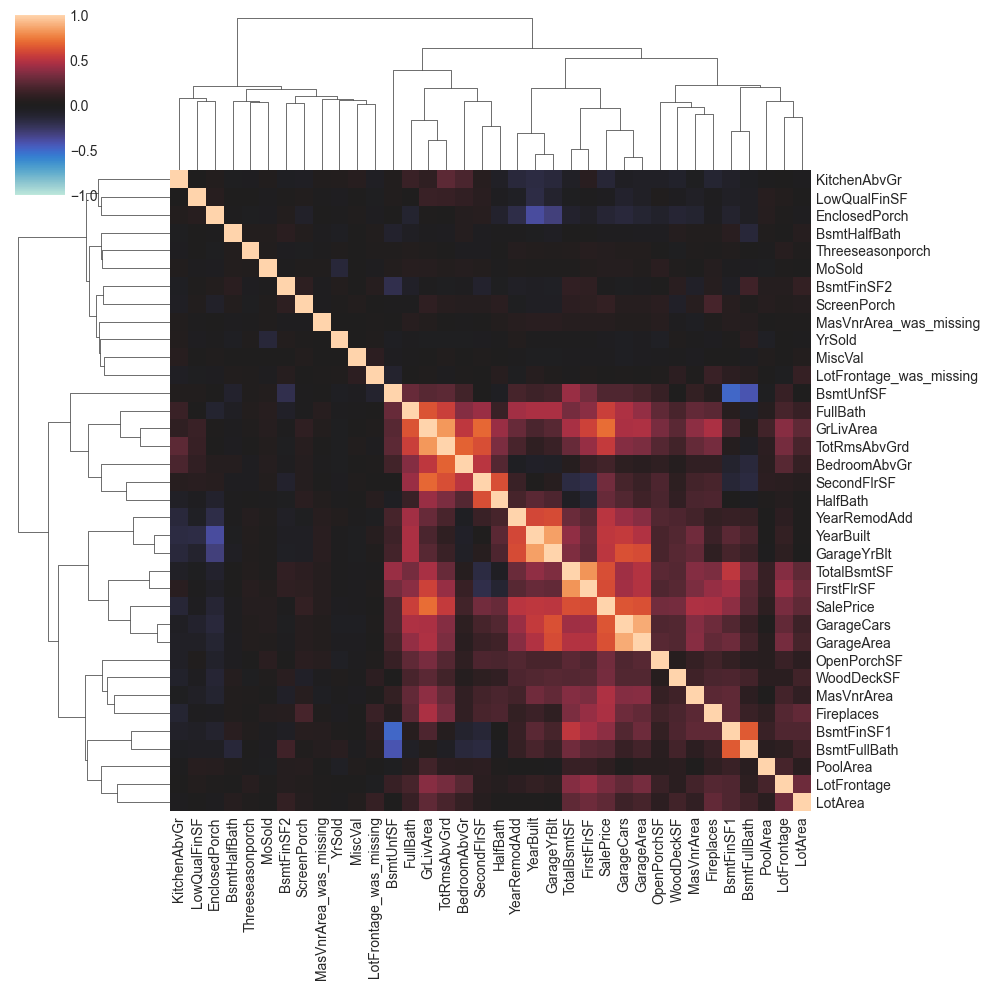

In [21]:
def corrplot(df, method="pearson", annot=True, **kwargs):
    # Compute numeric correlation matrix safely
    num = df.select_dtypes(include=["number"])
    corr = num.corr(method=method)
    # Drop rows/cols that are all NA and replace remaining non-finite with 0
    corr = corr.dropna(axis=0, how="all").dropna(axis=1, how="all")
    corr = corr.replace([np.inf, -np.inf], np.nan).fillna(0)
    # If too small for clustering, fall back to heatmap
    try:
        if corr.shape[0] >= 2 and corr.shape[1] >= 2:
            sns.clustermap(corr, vmin=-1.0, vmax=1.0, cmap="icefire", method="complete", annot=annot, **kwargs)
        else:
            raise ValueError("Not enough numeric columns for clustermap")
    except Exception:
        import warnings
        warnings.warn("Clustermap failed; falling back to heatmap.")
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr, vmin=-1.0, vmax=1.0, cmap="icefire", annot=annot, **kwargs)


corrplot(df_train, annot=None)

### PCA Application - Indicate Outliers ###

In [22]:
def indicate_outliers(df):
    X_new = pd.DataFrame()
    X_new["Outlier"] = (df.Neighborhood == "Edwards") & (df.SaleCondition == "Partial")
    return X_new


## Target Encoding ##

In [23]:

class CrossFoldEncoder:
    def __init__(self, encoder, **kwargs):
        self.encoder_ = encoder
        self.kwargs_ = kwargs  # keyword arguments for the encoder
        self.cv_ = KFold(n_splits=5, shuffle=True, random_state=0)

    def fit_transform(self, X, y, cols):
        self.fitted_encoders_ = []
        self.cols_ = cols
        X_encoded = []
        for idx_encode, idx_train in self.cv_.split(X):
            fitted_encoder = self.encoder_(cols=cols, **self.kwargs_)
            fitted_encoder.fit(X.iloc[idx_encode, :], y.iloc[idx_encode])
            X_encoded.append(fitted_encoder.transform(X.iloc[idx_train, :])[cols])
            self.fitted_encoders_.append(fitted_encoder)
        X_encoded = pd.concat(X_encoded).reindex(X.index)
        X_encoded.columns = [name + "_encoded" for name in X_encoded.columns]
        return X_encoded

    def transform(self, X):
        from functools import reduce
        X_encoded_list = []
        for fitted_encoder in self.fitted_encoders_:
            X_encoded = fitted_encoder.transform(X)
            X_encoded_list.append(X_encoded[self.cols_])
        X_encoded = reduce(lambda x, y: x.add(y, fill_value=0), X_encoded_list) / len(X_encoded_list)
        X_encoded.columns = [name + "_encoded" for name in X_encoded.columns]
        return X_encoded


## Create Final Feature Set ##

In [27]:
def create_features(df, df_test=None):
    X = df.copy()
    y = X.pop("SalePrice")
    mi_scores = make_mi_scores(X, y)

    if df_test is not None:
        X_test = df_test.copy()
        if "SalePrice" in X_test.columns:
            X_test.pop("SalePrice")
        X = pd.concat([X, X_test], copy=True)

    X = drop_uninformative(X, mi_scores)
    X = X.join(mathematical_transforms(X))
    X = X.join(interactions(X))
    X = X.join(counts(X))
    X = X.join(group_transforms(X))
    X = X.join(pca_inspired(X))

    # Ensure string/object columns become categorical to harmonize levels
    for col in X.select_dtypes(include=['object']).columns:
        X[col] = X[col].astype('category')

    X = label_encode(X)

    if df_test is not None:
        X_test = X.loc[df_test.index, :].copy()
        X.drop(df_test.index, inplace=True)

    encoder = CrossFoldEncoder(MEstimateEncoder, m=3)
    X = X.join(encoder.fit_transform(X, y, cols=["MSSubClass"]))
    if df_test is not None:
        X_test = X_test.join(encoder.transform(X_test))

    if df_test is not None:
        # Align columns between train and test
        if not X.columns.equals(X_test.columns):
            missing_in_test = set(X.columns) - set(X_test.columns)
            missing_in_train = set(X_test.columns) - set(X.columns)
            for c in missing_in_test:
                X_test[c] = 0
            for c in missing_in_train:
                X[c] = 0
        return X, X_test
    else:
        return X


df_train, df_test = load_data()
X_train = create_features(df_train)
y_train = df_train.loc[:, "SalePrice"]

score_dataset(X_train, y_train)

np.float64(0.13618205421566704)

# Step 4 - Hyperparameter Tuning #

In [25]:
X_train = create_features(df_train)
y_train = df_train.loc[:, "SalePrice"]

xgb_params = dict(
    max_depth=6,           # maximum depth of each tree - try 2 to 10
    learning_rate=0.01,    # effect of each tree - try 0.0001 to 0.1
    n_estimators=1000,     # number of trees (that is, boosting rounds) - try 1000 to 8000
    min_child_weight=1,    # minimum number of houses in a leaf - try 1 to 10
    colsample_bytree=0.7,  # fraction of features (columns) per tree - try 0.2 to 1.0
    subsample=0.7,         # fraction of instances (rows) per tree - try 0.2 to 1.0
    reg_alpha=0.5,         # L1 regularization (like LASSO) - try 0.0 to 10.0
    reg_lambda=1.0,        # L2 regularization (like Ridge) - try 0.0 to 10.0
    num_parallel_tree=1,   # set > 1 for boosted random forests
)

from sklearn.model_selection import RandomizedSearchCV
xgb = XGBRegressor(**xgb_params, tree_method="hist", n_jobs=-1, random_state=0)
score_dataset(X_train, y_train, xgb)

np.float64(0.12454306550159115)

# Step 5 - Train Model #

In [29]:
X_train, X_test = create_features(df_train, df_test)
y_train = df_train.loc[:, "SalePrice"]

from sklearn.base import clone
import joblib
xgb = XGBRegressor(**xgb_params, tree_method="hist", n_jobs=-1, random_state=0)
# XGB minimizes MSE, but competition loss is RMSLE
# So, we need to log-transform y to train and exp-transform the predictions
xgb.fit(X_train, np.log(y_train))
joblib.dump(xgb, 'xgb_trained.joblib')
predictions = np.exp(xgb.predict(X_test))
predictions = np.clip(predictions, a_min=2000, a_max=None)

output = pd.DataFrame({'Id': X_test.index, 'SalePrice': predictions})
output.to_csv('predictions.csv', index=False)
print("Your submission was successfully saved!")

# Optional: produce out-of-fold predictions for stacking
def get_oof_preds(model, X, y, n_splits=5):
    oof = np.zeros(X.shape[0])
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=0)
    for train_idx, val_idx in kf.split(X):
        model_ = clone(model)
        model_.fit(X.iloc[train_idx], np.log(y.iloc[train_idx]))
        oof[val_idx] = np.exp(model_.predict(X.iloc[val_idx]))
    return oof


Your submission was successfully saved!


---